## 1. Charger et prétraiter l'ensemble de données MNIST

In [1]:
# Importer les bibliothèques nécessaires
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Charger l'ensemble de données MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Normalisation des valeurs des pixels

In [2]:
# Normaliser les valeurs des pixels de l'image pour qu'elles soient comprises entre 0 et 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Forme de x_train après normalisation: {x_train.shape}, valeurs min: {np.min(x_train)}, max: {np.max(x_train)}")

Forme de x_train après normalisation: (60000, 28, 28), valeurs min: 0.0, max: 1.0


### Conversion des étiquettes au format encodé one-hot

In [3]:
# Convertir les étiquettes au format encodé one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Forme de y_train après encodage one-hot: {y_train.shape}")

Forme de y_train après encodage one-hot: (60000, 10)


### Afficher des exemples d'images avec leurs étiquettes correspondantes

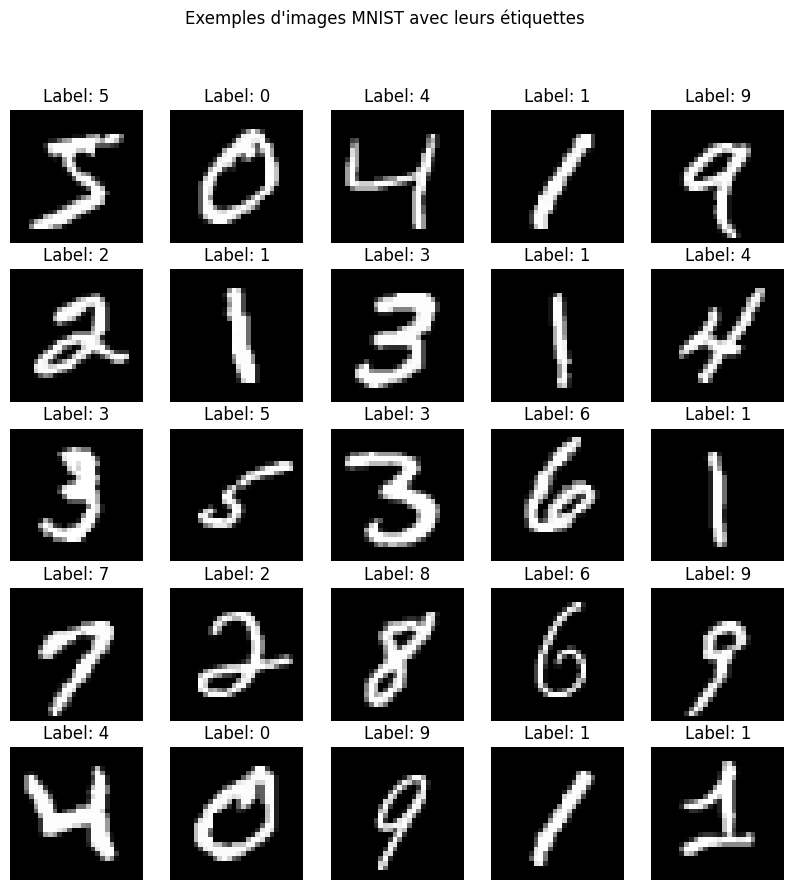

In [4]:
# Fonction pour convertir les étiquettes one-hot en entier
def one_hot_to_int(one_hot_array):
    return np.argmax(one_hot_array)

# Afficher des exemples d'images avec leurs étiquettes correspondantes
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {one_hot_to_int(y_train[i])}")
    plt.axis('off')
plt.suptitle('Exemples d\'images MNIST avec leurs étiquettes')
plt.show()

## 2. Construire un réseau neuronal entièrement connecté

### Définir un modèle séquentiel

In [8]:
# Définir le modèle séquentiel
model = tf.keras.models.Sequential([
    # Aplatir les images d'entrée 28x28 en un seul vecteur
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    # Première couche cachée avec activation ReLU
    tf.keras.layers.Dense(128, activation='relu'),
    # Deuxième couche cachée avec activation ReLU
    tf.keras.layers.Dense(64, activation='relu'),
    # Couche de sortie avec activation Softmax pour la classification multiclasse (10 chiffres)
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compiler le modèle

In [9]:
# Compiler le modèle en utilisant l'optimiseur Adam, l'entropie croisée catégorielle comme fonction de perte et la précision comme métrique d'évaluation.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Afficher un résumé du modèle
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraîner le réseau neuronal

In [10]:
# Entraîner le modèle
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9235 - loss: 0.2623 - val_accuracy: 0.9593 - val_loss: 0.1354
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9669 - loss: 0.1083 - val_accuracy: 0.9669 - val_loss: 0.1090
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0758 - val_accuracy: 0.9708 - val_loss: 0.0906
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9816 - loss: 0.0582 - val_accuracy: 0.9727 - val_loss: 0.0900
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9861 - loss: 0.0433 - val_accuracy: 0.9700 - val_loss: 0.1068
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0372 - val_accuracy: 0.9737 - val_loss: 0.0955
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0287 - val_accuracy: 0.9682 - val_loss: 0.1223
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9915 - loss: 0.0252 - 

### Observez les tendances en matière de perte et de précision au fil des époques

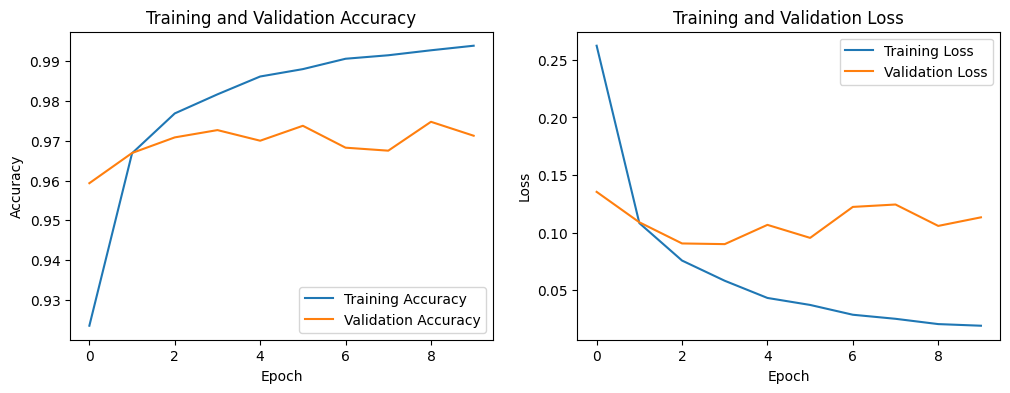

In [11]:
# Tracer la précision de l'entraînement et de la validation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Tracer la perte d'entraînement et de validation
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 4. Évaluer les performances du modèle

### Calculer la précision sur l'ensemble de données de test

In [12]:
# Évaluer le modèle sur l'ensemble de données de test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Précision sur l'ensemble de test: {accuracy:.4f}")
print(f"Perte sur l'ensemble de test: {loss:.4f}")

Précision sur l'ensemble de test: 0.9758
Perte sur l'ensemble de test: 0.0943


### Afficher une matrice de confusion pour les chiffres mal classés

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


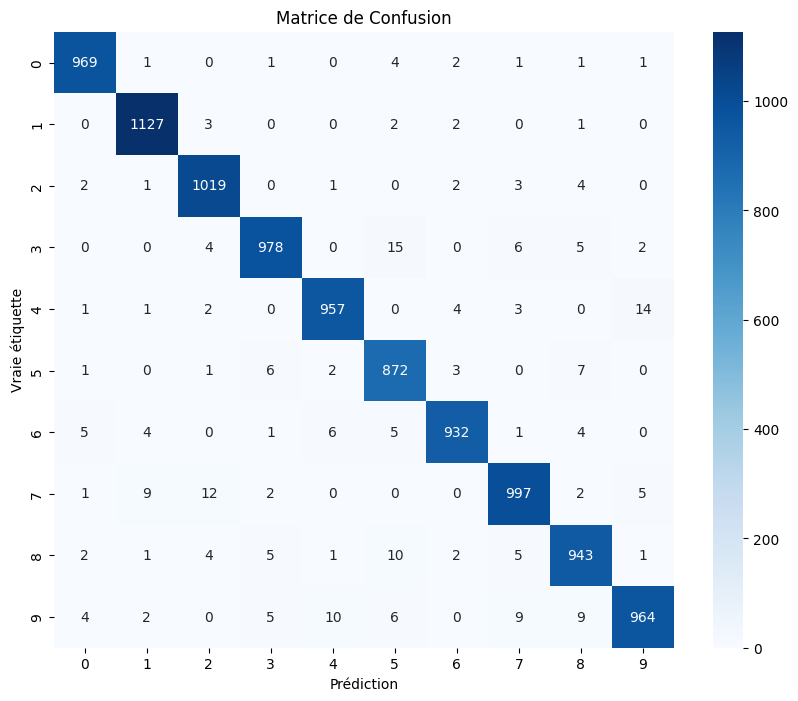

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtenir les prédictions du modèle sur l'ensemble de test
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Afficher la matrice de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Vraie étiquette')
plt.show()

### Identifier les chiffres avec lesquels le modèle a le plus de difficultés

Nombre total de prédictions incorrectes: 242


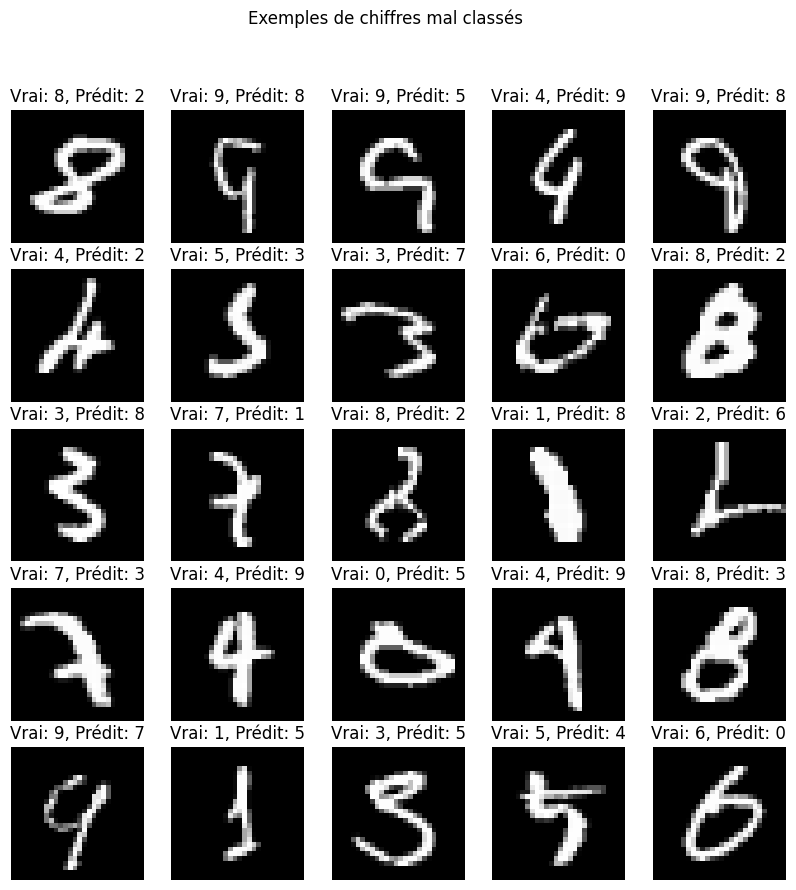

In [14]:
# Trouver les erreurs de classification
incorrect_indices = np.where(y_pred != y_true)[0]

print(f"Nombre total de prédictions incorrectes: {len(incorrect_indices)}")

# Afficher quelques exemples de chiffres mal classés
plt.figure(figsize=(10, 10))
for i, incorrect in enumerate(incorrect_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[incorrect].reshape(28, 28), cmap='gray')
    plt.title(f"Vrai: {y_true[incorrect]}, Prédit: {y_pred[incorrect]}")
    plt.axis('off')
plt.suptitle('Exemples de chiffres mal classés')
plt.show()

### Optimisation des performances du modèle grâce au réglage des hyperparamètres (Discussion)

Le réglage des hyperparamètres est une étape cruciale pour optimiser les performances d'un modèle de réseau neuronal. Voici quelques hyperparamètres clés que vous pourriez explorer et comment les ajuster:

*   **Taux d'apprentissage de l'optimiseur (Optimizer Learning Rate)**: Un taux d'apprentissage plus petit peut aider le modèle à converger plus précisément, mais il peut prendre plus de temps. Un taux plus grand peut converger plus rapidement mais risque de dépasser le minimum. Vous pouvez expérimenter avec des valeurs comme `0.01`, `0.001`, `0.0001`.
*   **Nombre d'époques (Epochs)**: C'est le nombre de fois que le modèle parcourt l'ensemble des données d'entraînement. Trop peu d'époques peuvent entraîner un sous-apprentissage, tandis que trop d'époques peuvent entraîner un surapprentissage. Nous avons utilisé 10 époques ici, mais vous pourriez essayer `20`, `50`, ou même `100`.
*   **Taille du lot (Batch Size)**: Le nombre d'échantillons d'entraînement traités avant la mise à jour des poids du modèle. Des tailles de lot plus petites peuvent introduire plus de bruit mais peuvent aider à une meilleure généralisation. Des tailles de lot plus grandes peuvent accélérer l'entraînement. Les valeurs courantes sont `32`, `64`, `128`.
*   **Nombre de couches cachées (Number of Hidden Layers)** et **Nombre de neurones par couche (Neurons per Layer)**: L'architecture du réseau. Ajouter plus de couches ou de neurones peut augmenter la capacité du modèle à apprendre des motifs complexes, mais peut également augmenter le risque de surapprentissage et le temps de calcul. Vous pourriez expérimenter avec `256`, `512` neurones ou ajouter une troisième couche cachée.
*   **Fonctions d'activation (Activation Functions)**: Bien que ReLU soit un choix populaire, d'autres fonctions comme Leaky ReLU, ELU ou tanh peuvent être explorées, en particulier dans les couches cachées.
*   **Régularisation (Regularization)**: Des techniques comme la régularisation L1/L2 ou le Dropout peuvent être ajoutées aux couches pour éviter le surapprentissage. Par exemple, `tf.keras.layers.Dropout(0.2)` après une couche Dense.

Pour une exploration systématique, des techniques comme la recherche sur grille (Grid Search) ou la recherche aléatoire (Random Search) avec des bibliothèques comme Keras Tuner ou Scikit-learn (avec un wrapper Keras) peuvent être utilisées. Cependant, cela va au-delà de la portée de ce défi quotidien pour un réseau neuronal simple.